Importing Libraries

In [1]:
!pip install xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

from xgboost import XGBRegressor

Loading Dataset

In [2]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


In [6]:
import zipfile, os

for file in uploaded.keys():
  with zipfile.ZipFile(file, 'r') as zip_ref:
    zip_ref.extractall('/content/data')

In [7]:
data = pd.read_csv('/content/data/Walmart.csv')

Feature Engineering

1.   Creating Proxy Prices



In [21]:
data['price'] = data['Fuel_Price']*10

data['demand'] = data['Weekly_Sales']

data['Date'] = pd.to_datetime(data['Date'], dayfirst=True)
data['month'] = data['Date'].dt.month
data['year'] = data['Date'].dt.year
data['week'] = data['Date'].dt.isocalendar().week
data['Store'] = data['Store'].astype('category').cat.codes
data['trend'] = np.arange(len(data))

Exploratory Data Analysis

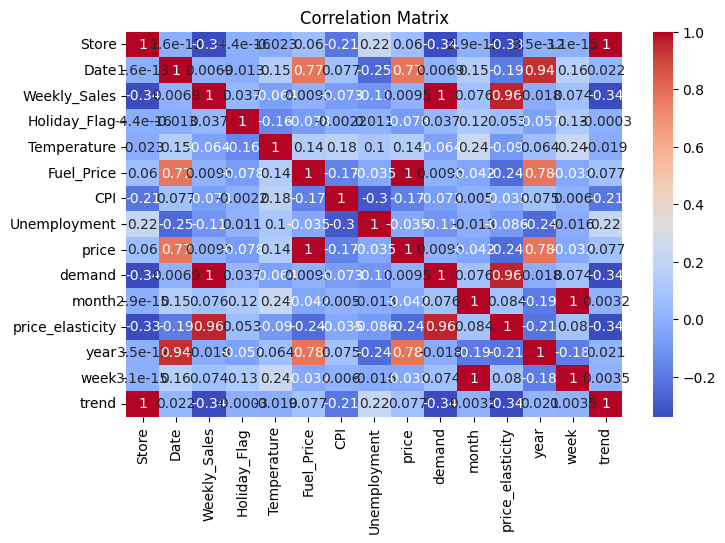

In [22]:
plt.figure(figsize=(8,5))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

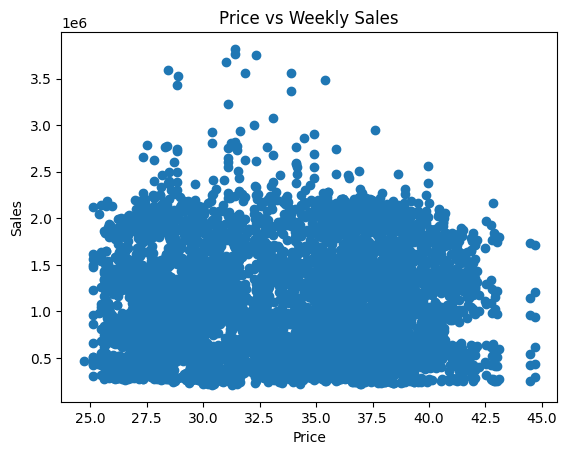

In [23]:
plt.scatter(data['price'], data['Weekly_Sales'])
plt.xlabel('Price')
plt.ylabel('Sales')
plt.title('Price vs Weekly Sales')
plt.show()

Price Elasticity Insight

In [24]:
data['price_elasticity'] = data['Weekly_Sales']/ data['price']

data[['price', 'Weekly_Sales', 'price_elasticity']].head()

,price,Weekly_Sales,price_elasticity
0,25.72,1643690.90,63907.111198
1,25.48,1641957.44,64441.029827
2,25.14,1611968.17,64119.656722
3,25.61,1409727.59,55045.981648
4,26.25,1554806.68,59230.730667


Preparing Data for ML

In [25]:
from re import X
features = ['Store', 'Temperature', 'Fuel_Price',
            'CPI', 'Unemployment', 'Holiday_Flag',
            'month', 'year', 'week', 'trend']
X = data[features]
y = data['Weekly_Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

Training Model (XGBoost)


In [26]:

model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

Evaluate Model

In [27]:
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error:', rmse)

Root Mean Squared Error: 87530.40698052534


Feature importance

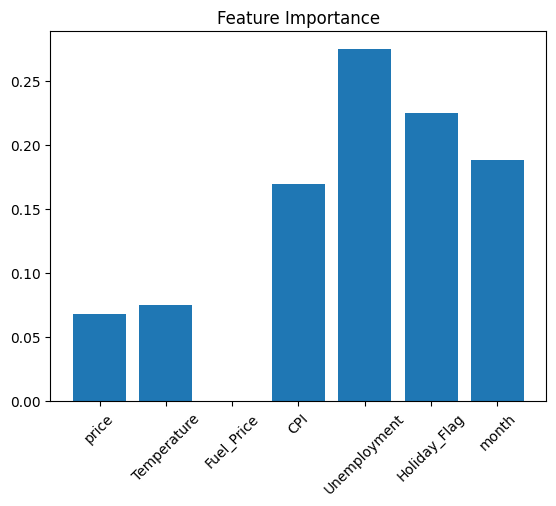

In [16]:
importances = model.feature_importances_

plt.bar(features, importances)
plt.title("Feature Importance")
plt.xticks(rotation=45)
plt.show()

What If Pricing Simulation

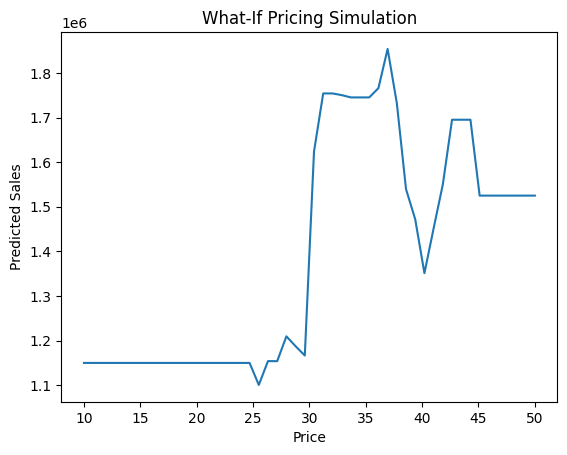

In [17]:
def simulate_price(price):
    sample = pd.DataFrame({
        'price': [price],
        'Temperature': [25],
        'Fuel_Price': [3],
        'CPI': [220],
        'Unemployment': [7],
        'Holiday_Flag': [0],
        'month': [6]
    })
    return model.predict(sample)[0]

prices = np.linspace(10, 50, 50)
predicted_sales = [simulate_price(p) for p in prices]

plt.plot(prices, predicted_sales)
plt.xlabel("Price")
plt.ylabel("Predicted Sales")
plt.title("What-If Pricing Simulation")
plt.show()